In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
df= pd.read_csv('/content/drive/MyDrive/ML LAB/Life_Expectancy.csv')
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [ ]:
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [ ]:
df.columns


Index(['Country', 'Year', 'Status', 'Life expectancy ', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure',
       'Diphtheria ', ' HIV/AIDS', 'GDP', 'Population',
       ' thinness  1-19 years', ' thinness 5-9 years',
       'Income composition of resources', 'Schooling'],
      dtype='object')

column description-

'Country'-Country

'Year'- Year

'Status'- Developed/developing

'Life expectancy '- Life Expectancy in age

'Adult Mortality'-Adult Mortality Rates of both sexes (probability of dying between 15 and 60 years per 1000 population)

'infant deaths'-Number of Infant Deaths per 1000 population

'Alcohol'-Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)

'percentage expenditure'-Expenditure on health as a percentage of Gross Domestic Product per capita(%)

'Hepatitis B'-Hepatitis B (HepB) immunization coverage among 1-year-olds (%)

'Measles '-Measles - number of reported cases per 1000 population

' BMI '-Average Body Mass Index of entire population

'under-five deaths '-Number of under-five deaths per 1000 population

'Polio'-Polio (Pol3) immunization coverage among 1-year-olds (%)

'Total expenditure'-General government expenditure on health as a percentage of total government expenditure (%)

'Diphtheria '-Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)

' HIV/AIDS'-Deaths per 1 000 live births HIV/AIDS (0-4 years)

'GDP'-Gross Domestic Product per capita (in USD)

'Population'-Population of the country

' thinness  1-19 years'-Prevalence of thinness among children and adolescents for Age 10 to 19 (% )

' thinness 5-9 years'-Prevalence of thinness among children and adolescents for Age 5 to 9 (% )

'Income composition of resources'-Human Development Index in terms of income composition of resources (index ranging from 0 to 1)

'Schooling'-Number of years of Schooling(years)


In [ ]:
df.columns = df.columns.str.replace(' ', '')

In [ ]:
print(df.columns)

Index(['Country', 'Year', 'Status', 'Lifeexpectancy', 'AdultMortality',
       'infantdeaths', 'Alcohol', 'percentageexpenditure', 'HepatitisB',
       'Measles', 'BMI', 'under-fivedeaths', 'Polio', 'Totalexpenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
Population,652
HepatitisB,553
GDP,448
Totalexpenditure,226
Alcohol,194
Incomecompositionofresources,167
Schooling,163
thinness1-19years,34
thinness5-9years,34
BMI,34


In [ ]:
import pandas as pd

# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Calculate skewness
skewness = df[num_cols].skew().sort_values(ascending=False)

skewness

,0
Population,15.916236
infantdeaths,9.786963
under-fivedeaths,9.495065
Measles,9.441332
HIV/AIDS,5.396112
percentageexpenditure,4.652051
GDP,3.206655
thinness5-9years,1.777424
thinness1-19years,1.711471
AdultMortality,1.174369


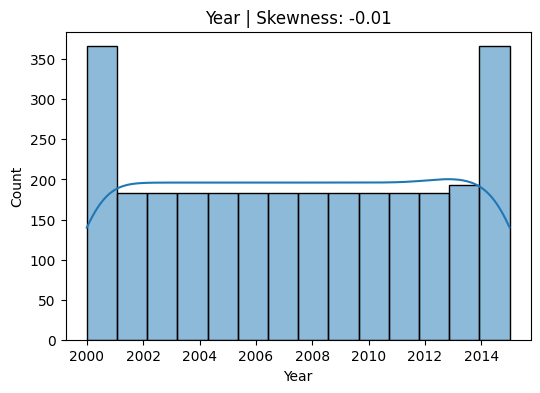

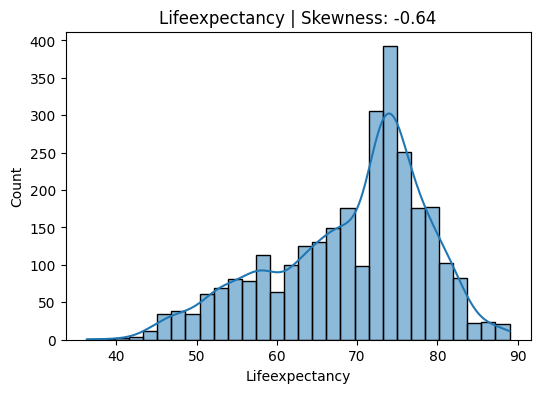

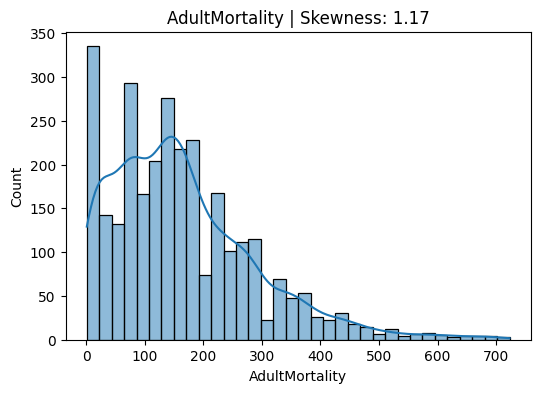

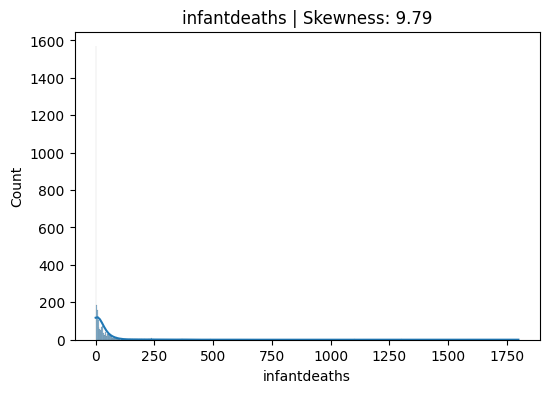

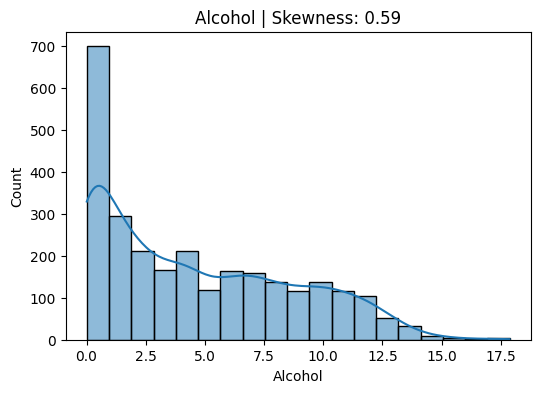

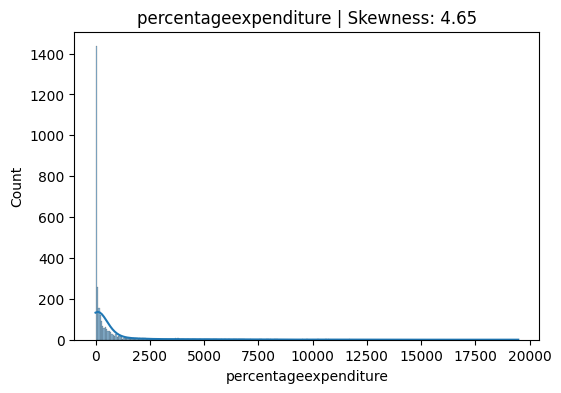

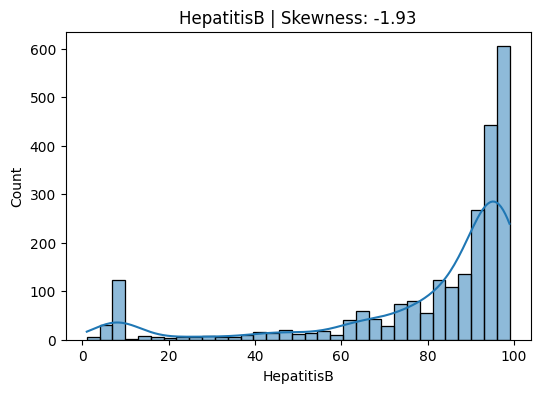

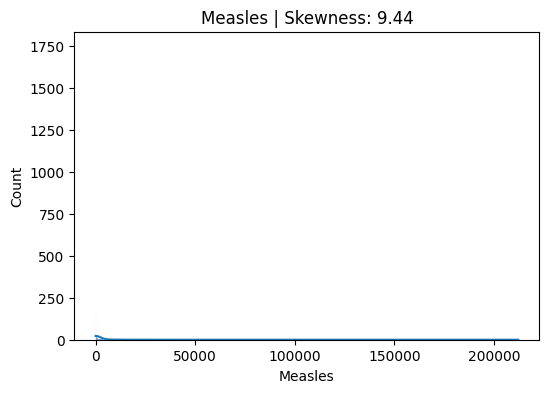

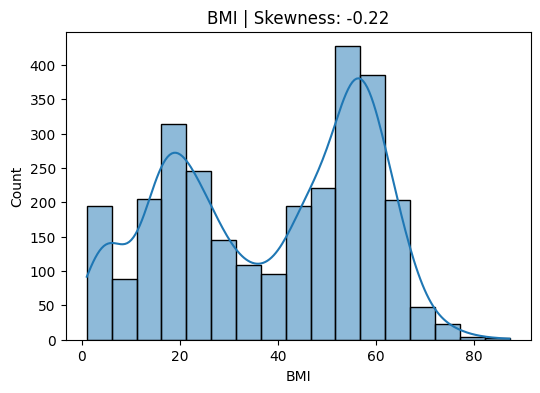

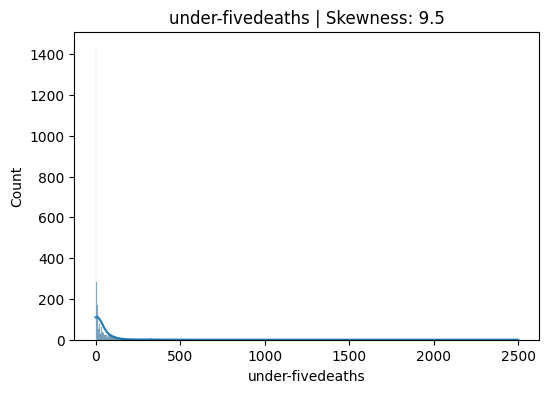

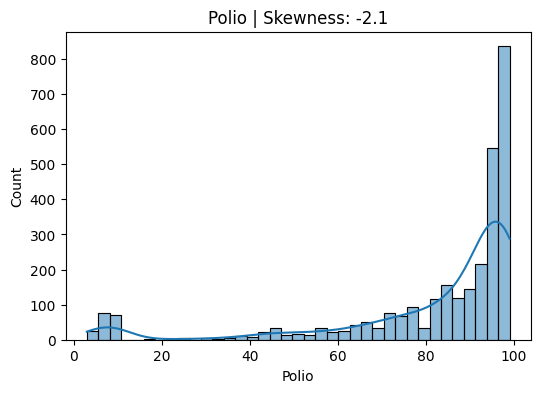

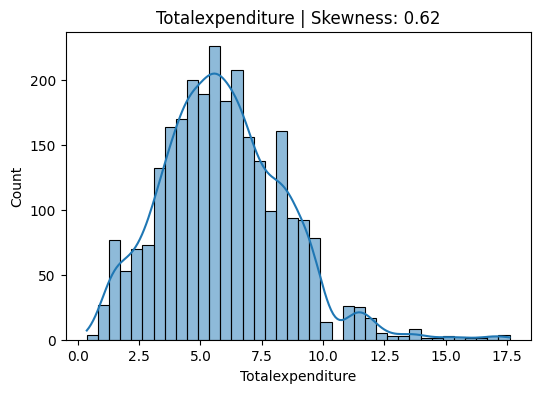

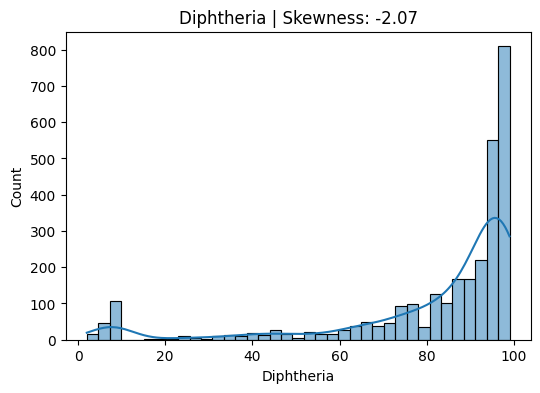

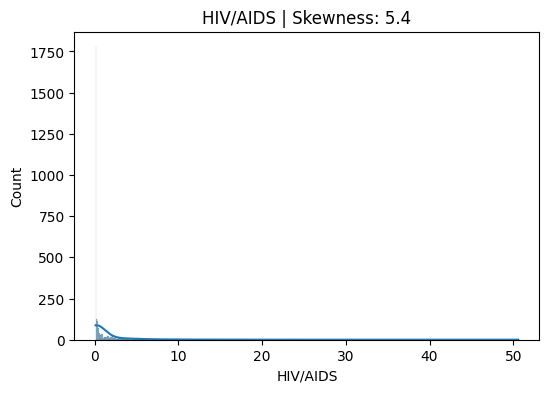

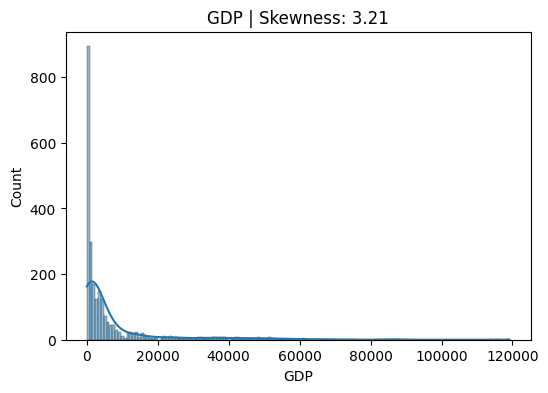

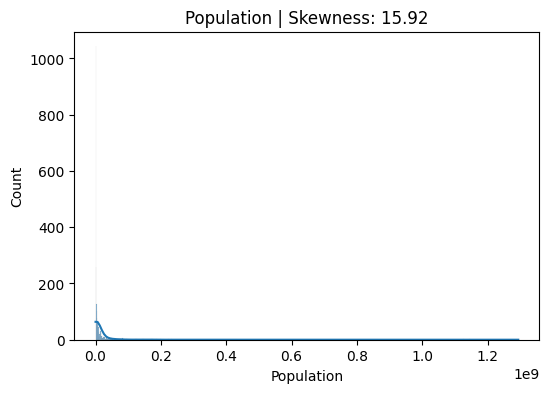

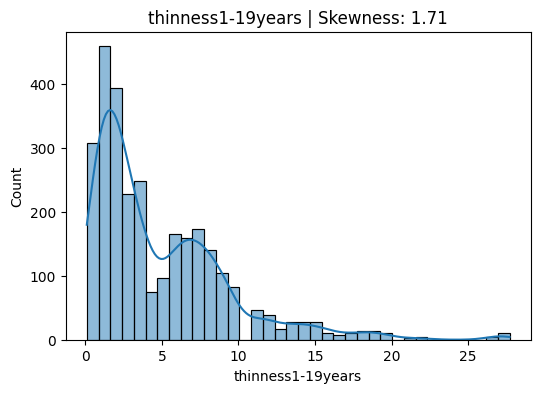

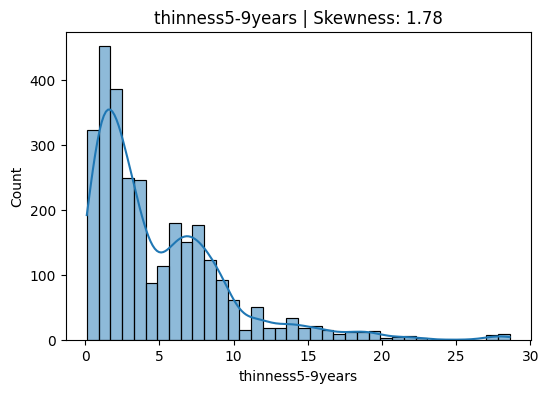

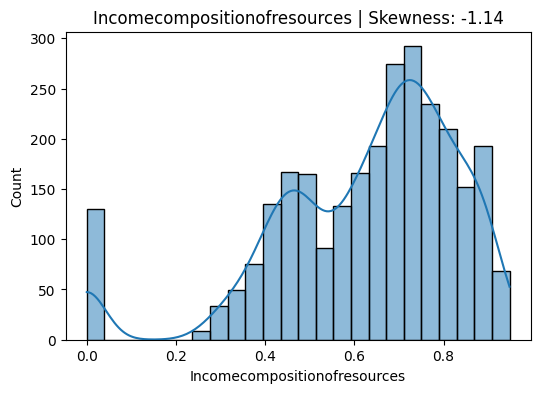

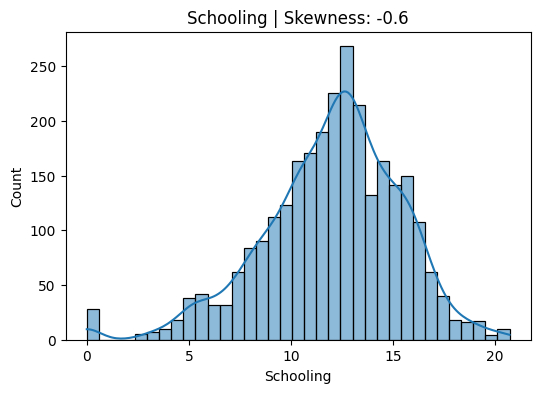

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
for col in num_cols:
    skew_val = df[col].skew()

    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} | Skewness: {round(skew_val, 2)}')
    plt.show()

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
skewness = df[num_cols].skew()
import numpy as np

def country_impute(group):
    for col in num_cols:
        if col == 'Life_expectancy':  # never touch target
            continue

        if group[col].isnull().sum() > 0:

            # Choose strategy based on global skewness
            if abs(skewness[col]) > 1:
                fill_value = group[col].median()
            else:
                fill_value = group[col].mean()

            # Fallback if country-level stat is NaN
            if np.isnan(fill_value):
                if abs(skewness[col]) > 1:
                    fill_value = df[col].median()
                else:
                    fill_value = df[col].mean()

            group[col] = group[col].fillna(fill_value)

    return group
df = df.groupby("Country").apply(country_impute)
df.reset_index(drop=True, inplace=True)


/tmp/ipykernel_12054/3219869248.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("Country").apply(country_impute)


In [ ]:
df.groupby('Country').apply(lambda x: x.isnull().sum())


/tmp/ipykernel_12054/1165125632.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Country').apply(lambda x: x.isnull().sum())


,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
Country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albania,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Algeria,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Angola,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Antigua and Barbuda,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Venezuela (Bolivarian Republic of),0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Viet Nam,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Yemen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import pandas as pd
import numpy as np

skewness = df.skew(numeric_only=True)

high_skew_cols = skewness[abs(skewness) > 1].index
low_skew_cols = skewness[abs(skewness) <= 1].index

for col in high_skew_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df.groupby("Country")[col].transform("median"))

for col in low_skew_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df.groupby("Country")[col].transform("mean"))



In [ ]:
df.isnull().sum()

,0
Country,0
Year,0
Status,0
Lifeexpectancy,0
AdultMortality,0
infantdeaths,0
Alcohol,0
percentageexpenditure,0
HepatitisB,0
Measles,0


In [ ]:
#tranformation
percent_cols = ["HepatitisB","Polio","Diphtheria","thinness1-19years","thinness5-9years"]
df[percent_cols] = df[percent_cols] / 100
per1000_cols = ["AdultMortality","infantdeaths","under-fivedeaths"]
df[percent_cols] = df[percent_cols] / 100


In [ ]:
import numpy as np
import pandas as pd

cols = ["infantdeaths","percentageexpenditure","Measles","under-fivedeaths", "HIV/AIDS","GDP","Population"]

print("Original Skewness:")
print(df[cols].skew())

df[cols] = np.log1p(df[cols])

print("\nSkewness After log1p Transformation:")
print(df[cols].skew())


Original Skewness:
infantdeaths              9.786963
percentageexpenditure     4.652051
Measles                   9.441332
under-fivedeaths          9.495065
HIV/AIDS                  5.396112
GDP                       3.542304
Population               17.972921
dtype: float64

Skewness After log1p Transformation:
infantdeaths             0.701769
percentageexpenditure   -0.078266
Measles                  0.555483
under-fivedeaths         0.647154
HIV/AIDS                 2.127285
GDP                     -0.140659
Population              -0.701546
dtype: float64


In [ ]:
df["Status"]=df["Status"].map({"Developing":0,"Developed":1})
df["Status"].head()

,Status
0,0
1,0
2,0
3,0
4,0


In [ ]:
X = df.drop(columns=["Lifeexpectancy","Country"])
y = df["Lifeexpectancy"]

In [ ]:
from sklearn.preprocessing import StandardScaler
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
num_cols = num_cols.drop("Status")
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

In [ ]:
df.dtypes

,0
Country,object
Year,int64
Status,int64
Lifeexpectancy,float64
AdultMortality,float64
infantdeaths,float64
Alcohol,float64
percentageexpenditure,float64
HepatitisB,float64
Measles,float64


In [ ]:
df

,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,Afghanistan,2015,0,65.0,263.0,4.143135,0.01,4.280542,0.0065,7.051856,...,0.0006,8.16,0.0065,0.095310,6.372055,17.334091,0.00172,0.00173,0.479,10.1
1,Afghanistan,2014,0,59.9,271.0,4.174387,0.01,4.311116,0.0062,6.200509,...,0.0058,8.18,0.0062,0.095310,6.419501,12.699497,0.00175,0.00175,0.476,10.0
2,Afghanistan,2013,0,59.9,268.0,4.204693,0.01,4.307023,0.0064,6.066108,...,0.0062,8.13,0.0064,0.095310,6.450067,17.272826,0.00177,0.00177,0.470,9.9
3,Afghanistan,2012,0,59.5,272.0,4.248495,0.01,4.371777,0.0067,7.933080,...,0.0067,8.52,0.0067,0.095310,6.508708,15.123021,0.00179,0.00180,0.463,9.8
4,Afghanistan,2011,0,59.2,275.0,4.276666,0.01,2.091507,0.0068,8.011023,...,0.0068,7.87,0.0068,0.095310,4.167242,14.906964,0.00182,0.00182,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,0,44.3,723.0,3.332205,4.36,0.000000,0.0068,3.465736,...,0.0067,7.13,0.0065,3.543854,6.121103,16.363197,0.00094,0.00094,0.407,9.2
2934,Zimbabwe,2003,0,44.5,715.0,3.295837,4.06,0.000000,0.0007,6.906755,...,0.0007,6.52,0.0068,3.629660,6.118870,16.351894,0.00098,0.00099,0.418,9.5
2935,Zimbabwe,2002,0,44.8,73.0,3.258097,4.43,0.000000,0.0073,5.720312,...,0.0073,6.53,0.0071,3.708682,4.066431,11.740268,0.00012,0.00013,0.427,10.0
2936,Zimbabwe,2001,0,45.3,686.0,3.258097,1.72,0.000000,0.0076,6.272877,...,0.0076,6.16,0.0075,3.763523,6.309168,16.330475,0.00016,0.00017,0.427,9.8


In [ ]:
X= df.drop(columns=["Measles","thinness5-9years","under-fivedeaths"])
y=df["Lifeexpectancy"]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Only Country needs transformation → everything else is already ready
preprocessor = ColumnTransformer(
    transformers=[
        ('country', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['Country']),
    ],
    remainder='passthrough'          # ← very important: keep scaled numerics unchanged
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

# Same split as above
X = df.drop(columns=['Lifeexpectancy'])
y = df['Lifeexpectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = pipeline.score(X_test, y_test)

print(f"R²:       {r2:8.4f}")
print(f"MAE:      {mae:.3f} years")
print(f"MSE:      {mse:.3f}")
print(f"RMSE:     {rmse:.3f} years")

R²:         0.9601
MAE:      1.228 years
MSE:      3.613
RMSE:     1.901 years


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
!pip install -q ipywidgets joblib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 36.0 MB/s eta 0:00:00


In [ ]:
import joblib
joblib.dump(pipeline, '/content/life_expectancy_model.joblib')

['/content/life_expectancy_model.joblib']

In [ ]:
X.columns

Index(['Country', 'Year', 'Status', 'AdultMortality', 'infantdeaths',
       'Alcohol', 'percentageexpenditure', 'HepatitisB', 'Measles', 'BMI',
       'under-fivedeaths', 'Polio', 'Totalexpenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness1-19years',
       'thinness5-9years', 'Incomecompositionofresources', 'Schooling'],
      dtype='object')

In [ ]:
df[['under-fivedeaths','infantdeaths']].corr()

,under-fivedeaths,infantdeaths
under-fivedeaths,1.000000,0.996315
infantdeaths,0.996315,1.000000


In [ ]:
df[['Polio','Measles']].corr()

,Polio,Measles
Polio,1.000000,-0.242919
Measles,-0.242919,1.000000


In [ ]:
df[['thinness5-9years','thinness1-19years']].corr()

,thinness5-9years,thinness1-19years
thinness5-9years,1.000000,0.939187
thinness1-19years,0.939187,1.000000


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Only Country needs transformation → everything else is already ready
preprocessor = ColumnTransformer(
    transformers=[
        ('country', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), ['Country']),
    ],
    remainder='passthrough'          # ← very important: keep scaled numerics unchanged
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

# Same split as above
X = df.drop(columns=['Lifeexpectancy','under-fivedeaths','thinness5-9years','Schooling','GDP'])
y = df['Lifeexpectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = pipeline.score(X_test, y_test)

print(f"R²:       {r2:8.4f}")
print(f"MAE:      {mae:.3f} years")
print(f"MSE:      {mse:.3f}")
print(f"RMSE:     {rmse:.3f} years")

R²:         0.9594
MAE:      1.258 years
MSE:      3.674
RMSE:     1.917 years


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
df


,Country,Year,Status,Lifeexpectancy,AdultMortality,infantdeaths,Alcohol,percentageexpenditure,HepatitisB,Measles,...,Polio,Totalexpenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness1-19years,thinness5-9years,Incomecompositionofresources,Schooling
0,Afghanistan,2015,0,65.0,263.0,4.143135,0.01,4.280542,0.0065,7.051856,...,0.0006,8.16,0.0065,0.095310,6.372055,17.334091,0.00172,0.00173,0.479,10.1
1,Afghanistan,2014,0,59.9,271.0,4.174387,0.01,4.311116,0.0062,6.200509,...,0.0058,8.18,0.0062,0.095310,6.419501,12.699497,0.00175,0.00175,0.476,10.0
2,Afghanistan,2013,0,59.9,268.0,4.204693,0.01,4.307023,0.0064,6.066108,...,0.0062,8.13,0.0064,0.095310,6.450067,17.272826,0.00177,0.00177,0.470,9.9
3,Afghanistan,2012,0,59.5,272.0,4.248495,0.01,4.371777,0.0067,7.933080,...,0.0067,8.52,0.0067,0.095310,6.508708,15.123021,0.00179,0.00180,0.463,9.8
4,Afghanistan,2011,0,59.2,275.0,4.276666,0.01,2.091507,0.0068,8.011023,...,0.0068,7.87,0.0068,0.095310,4.167242,14.906964,0.00182,0.00182,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,Zimbabwe,2004,0,44.3,723.0,3.332205,4.36,0.000000,0.0068,3.465736,...,0.0067,7.13,0.0065,3.543854,6.121103,16.363197,0.00094,0.00094,0.407,9.2
2934,Zimbabwe,2003,0,44.5,715.0,3.295837,4.06,0.000000,0.0007,6.906755,...,0.0007,6.52,0.0068,3.629660,6.118870,16.351894,0.00098,0.00099,0.418,9.5
2935,Zimbabwe,2002,0,44.8,73.0,3.258097,4.43,0.000000,0.0073,5.720312,...,0.0073,6.53,0.0071,3.708682,4.066431,11.740268,0.00012,0.00013,0.427,10.0
2936,Zimbabwe,2001,0,45.3,686.0,3.258097,1.72,0.000000,0.0076,6.272877,...,0.0076,6.16,0.0075,3.763523,6.309168,16.330475,0.00016,0.00017,0.427,9.8


In [ ]:
df.isnull().sum()

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------------
# 1️⃣ Remove selected columns
# -----------------------------------
df_reduced = df.drop(columns=[
    'under-fivedeaths',
    'thinness1-19years'
])

# -----------------------------------
# 2️⃣ Define X and y
# -----------------------------------
X = df_reduced.drop(columns=['Lifeexpectancy'])
y = df_reduced['Lifeexpectancy']

# -----------------------------------
# 3️⃣ Feature Groups
# -----------------------------------
categorical_features = ['Country']

# Do NOT scale Status
numeric_features = X.drop(columns=['Country', 'Status']).columns

binary_feature = ['Status']  # pass through unchanged

# -----------------------------------
# 4️⃣ Preprocessor
# -----------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('country', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features),
        ('status', 'passthrough', binary_feature)
    ]
)

# -----------------------------------
# 5️⃣ Pipeline
# -----------------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

# -----------------------------------
# 6️⃣ Train-Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# -----------------------------------
# 7️⃣ Train Model
# -----------------------------------
pipeline.fit(X_train, y_train)

# -----------------------------------
# 8️⃣ Predict
# -----------------------------------
y_pred = pipeline.predict(X_test)

# -----------------------------------
# 9️⃣ Evaluate
# -----------------------------------
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = pipeline.score(X_test, y_test)

print("Model (Scaled Except Status)")
print("-----------------------------")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.3f} years")
print(f"RMSE: {rmse:.3f} years")


Model (Scaled Except Status)
-----------------------------
R²:   0.9600
MAE:  1.245 years
RMSE: 1.904 years


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

# -----------------------------------
# 1️⃣ Remove selected columns
# -----------------------------------
df_reduced = df.drop(columns=[
    'under-fivedeaths',
    'thinness1-19years',
    'Schooling'
])

# -----------------------------------
# 2️⃣ Define X and y
# -----------------------------------
X = df_reduced.drop(columns=['Lifeexpectancy'])
y = df_reduced['Lifeexpectancy']

# -----------------------------------
# 3️⃣ Feature Groups
# -----------------------------------
categorical_features = ['Country']

# Do NOT scale Status
numeric_features = X.drop(columns=['Country', 'Status']).columns

binary_feature = ['Status']  # pass through unchanged

# -----------------------------------
# 4️⃣ Preprocessor
# -----------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('country', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features),
        ('status', 'passthrough', binary_feature)
    ]
)

# -----------------------------------
# 5️⃣ Pipeline
# -----------------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

# -----------------------------------
# 6️⃣ Train-Test Split
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

# -----------------------------------
# 7️⃣ Train Model
# -----------------------------------
pipeline.fit(X_train, y_train)

# -----------------------------------
# 8️⃣ Predict
# -----------------------------------
y_pred = pipeline.predict(X_test)

# -----------------------------------
# 9️⃣ Evaluate
# -----------------------------------
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = pipeline.score(X_test, y_test)

print("Model (Scaled Except Status)")
print("-----------------------------")
print(f"R²:   {r2:.4f}")
print(f"MAE:  {mae:.3f} years")
print(f"RMSE: {rmse:.3f} years")


Model (Scaled Except Status)
-----------------------------
R²:   0.9602
MAE:  1.261 years
RMSE: 1.899 years


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
df[['Schooling', 'GDP', 'Status', 'AdultMortality']].corr()

,Schooling,GDP,Status,AdultMortality
Schooling,1.000000,0.581318,0.491444,-0.434756
GDP,0.581318,1.000000,0.409658,-0.351042
Status,0.491444,0.409658,1.000000,-0.314894
AdultMortality,-0.434756,-0.351042,-0.314894,1.000000


In [ ]:
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

# -----------------------------------
# 1️⃣ Remove selected columns
# -----------------------------------
df_final = df.drop(columns=[
    'under-fivedeaths',
    'thinness1-19years'
])

# -----------------------------------
# 2️⃣ Define X and y
# -----------------------------------
X = df_final.drop(columns=['Lifeexpectancy'])
y = df_final['Lifeexpectancy']

# -----------------------------------
# 3️⃣ Feature Groups
# -----------------------------------
categorical_features = ['Country']
numeric_features = X.drop(columns=['Country', 'Status']).columns
binary_feature = ['Status']

# -----------------------------------
# 4️⃣ Preprocessor
# -----------------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('country', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numeric_features),
        ('status', 'passthrough', binary_feature)
    ]
)

# -----------------------------------
# 5️⃣ Pipeline
# -----------------------------------
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

# -----------------------------------
# 6️⃣ Train
# -----------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

pipeline.fit(X_train, y_train)

# -----------------------------------
# 7️⃣ Save model
# -----------------------------------
joblib.dump(pipeline, "life_expectancy_model.pkl")

print("Model saved successfully.")


Model saved successfully.


In [ ]:
import joblib

model = joblib.load("life_expectancy_model.pkl")
print("Model loaded successfully.")


Model loaded successfully.
